# Medidas de Posição e Dispersão — Fundos de Investimento (CVM)

**Atividade:** Medidas de tendência central, dispersão, visualizações e conceito de modelo  
**Dataset:** Informes Diários e Cadastro de Fundos de Investimento — CVM  
**Fonte:** [dados.cvm.gov.br](https://dados.cvm.gov.br)

---

## Contexto

Depois de aprender a classificar variáveis, o próximo passo é **resumir os dados numericamente**.  
As **medidas de tendência central** (média, mediana, moda) respondem: *"qual valor representa melhor esse conjunto de dados?"*  
As **medidas de dispersão** (variância, desvio padrão) respondem: *"os dados estão concentrados ou espalhados?"*

Usaremos os mesmos dados da CVM para aplicar esses conceitos em um contexto real de mercado de capitais.

## 1. Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 4)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Download dos Dados

Reutilizamos os mesmos datasets da CVM do notebook anterior.

In [2]:
def baixar_cvm_csv(url: str, encoding: str = "latin1") -> pd.DataFrame:
    """Baixa um arquivo CSV (ou ZIP contendo CSV) da CVM e retorna como DataFrame."""
    print(f"Baixando: {url}")
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    response = requests.get(url, timeout=120, headers=headers)
    response.raise_for_status()

    if url.endswith(".zip"):
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            nome_csv = [f for f in z.namelist() if f.endswith(".csv")][0]
            with z.open(nome_csv) as f:
                return pd.read_csv(f, sep=";", encoding=encoding, low_memory=False)
    return pd.read_csv(io.BytesIO(response.content), sep=";", encoding=encoding, low_memory=False)


# Cadastro de fundos
cad = baixar_cvm_csv("https://dados.cvm.gov.br/dados/FI/CAD/DADOS/cad_fi.csv")

# Informes diários — mês recente
inf = baixar_cvm_csv("https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202502.zip")

# Conversões de tipo
inf["DT_COMPTC"] = pd.to_datetime(inf["DT_COMPTC"])
cad["SIT"] = cad["SIT"].str.strip().str.upper()

print(f"\nCadastro: {cad.shape[0]:,} fundos | Informes: {inf.shape[0]:,} registros")

Baixando: https://dados.cvm.gov.br/dados/FI/CAD/DADOS/cad_fi.csv


Baixando: https://dados.cvm.gov.br/dados/FI/DOC/INF_DIARIO/DADOS/inf_diario_fi_202502.zip



Cadastro: 46,810 fundos | Informes: 512,125 registros


## 3. Medidas de Tendência Central

As medidas de tendência central buscam representar um conjunto de dados com um único valor "típico".  
As três principais são:

| Medida | O que calcula | Quando usar |
|--------|--------------|-------------|
| **Média** | Soma dividida pela quantidade de valores | Variáveis numéricas sem outliers extremos |
| **Mediana** | Valor do meio quando os dados estão ordenados | Variáveis numéricas com outliers ou distribuição assimétrica |
| **Moda** | Valor mais frequente | Variáveis categóricas; também útil em numéricas discretas |

---

### 3.1 Média

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

onde:
- $\bar{x}$ — média aritmética
- $n$ — quantidade de observações
- $x_i$ — valor da $i$-ésima observação

É a soma de todos os valores dividida pela quantidade de observações. Sensível a valores extremos (outliers) — um único fundo com patrimônio bilionário eleva a média muito acima do valor típico da maioria dos fundos.

### 3.2 Mediana

Quando os dados estão ordenados do menor para o maior, a mediana é o valor do meio. Se houver número par de observações, é a média dos dois valores centrais.

$$\tilde{x} = \begin{cases} x_{\frac{n+1}{2}} & \text{se } n \text{ ímpar} \\ \dfrac{x_{\frac{n}{2}} + x_{\frac{n}{2}+1}}{2} & \text{se } n \text{ par} \end{cases}$$

Não é afetada por outliers — se um fundo tem patrimônio de R$ 100 bilhões, a mediana dos demais não muda. Por isso representa melhor o fundo "típico" do mercado.

onde:
- $\tilde{x}$ — mediana
- $n$ — quantidade de observações
- $x_{\frac{n+1}{2}}$ — elemento central quando $n$ é ímpar
- $x_{\frac{n}{2}}$ e $x_{\frac{n}{2}+1}$ — os dois elementos centrais quando $n$ é par

### 3.3 Moda

É o valor (ou categoria) que aparece com maior frequência. Pode haver mais de uma moda (distribuição bimodal ou multimodal), ou nenhuma, se todos os valores forem igualmente frequentes.

Não tem fórmula algébrica — é identificada por contagem. É a única medida de tendência central aplicável a variáveis categóricas.

In [3]:
# Patrimônio líquido médio por fundo (último dia disponível)
ultimo_dia = inf["DT_COMPTC"].max()
inf_ultimo = inf[inf["DT_COMPTC"] == ultimo_dia].copy()

pl = inf_ultimo["VL_PATRIM_LIQ"].dropna()
pl = pl[pl > 0]

media_pl   = pl.mean()
mediana_pl = pl.median()
moda_tp    = cad["TP_FUNDO"].mode()[0]

print(f"Data de referência: {ultimo_dia.date()}")
print(f"\nPatrimônio Líquido (R$):")
print(f"  Média   : R$ {media_pl:>20,.2f}")
print(f"  Mediana : R$ {mediana_pl:>20,.2f}")
print(f"\nTipo de fundo mais comum (moda): {moda_tp}")

Data de referência: 2025-02-28

Patrimônio Líquido (R$):
  Média   : R$       469,571,755.18
  Mediana : R$        43,014,254.43

Tipo de fundo mais comum (moda): FI


### 3.4 Diferença entre Média e Mediana

As duas medem o centro dos dados, mas de formas diferentes:

- A **média** usa todos os valores no cálculo — um valor muito alto ou muito baixo altera o resultado
- A **mediana** olha apenas para a posição central — valores extremos não a afetam

**Exemplo:** imagine 5 fundos com patrimônio de R&nbsp;$ 1 M, R&nbsp;$ 2 M, R&nbsp;$ 3 M, R&nbsp;$ 4 M e R&nbsp;$ 100 M:

| Medida | Resultado | Observação |
|--------|-----------|------------|
| Média | R$ 22 M | Puxada pelo fundo grande |
| Mediana | R$ 3 M | O valor do meio, que representa melhor os demais |

Quando os valores são próximos entre si, média e mediana chegam a resultados parecidos. Quando há valores muito discrepantes, elas divergem — e a mediana tende a representar melhor o valor típico do conjunto.

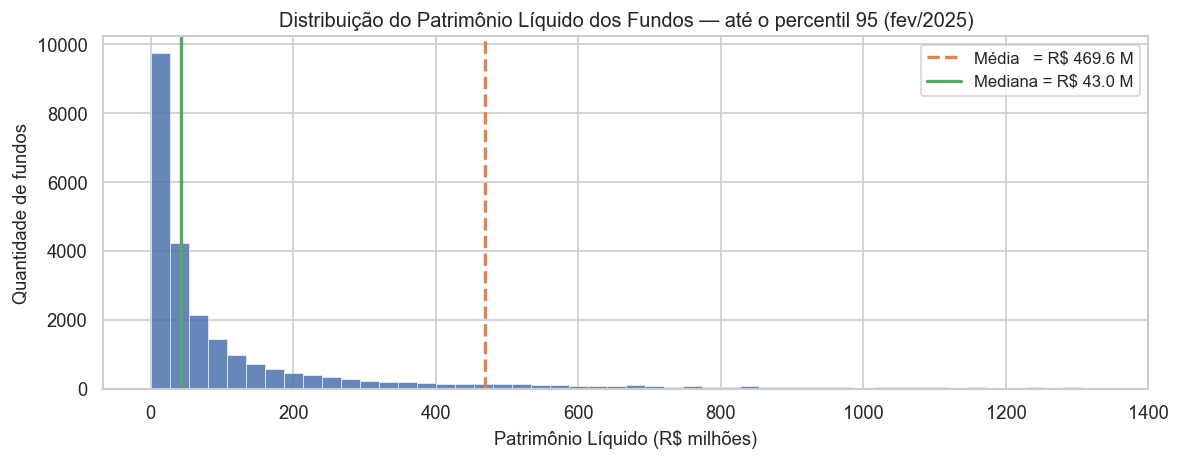

In [4]:
# Filtro até o percentil 95 para remover os megafundos e mostrar onde a maioria está
p95 = pl.quantile(0.95)
pl_plot = pl[pl <= p95] / 1e6  # converter para R$ milhões

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pl_plot, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.4, alpha=0.85)

ax.axvline(media_pl / 1e6,   color="#DD8452", linewidth=2, linestyle="--",
           label=f"Média   = R$ {media_pl/1e6:.1f} M")
ax.axvline(mediana_pl / 1e6, color="#55A868", linewidth=2, linestyle="-",
           label=f"Mediana = R$ {mediana_pl/1e6:.1f} M")

ax.set_xlabel("Patrimônio Líquido (R$ milhões)", fontsize=11)
ax.set_ylabel("Quantidade de fundos", fontsize=11)
ax.set_title("Distribuição do Patrimônio Líquido dos Fundos — até o percentil 95 (fev/2025)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 4. Medidas de Dispersão: Variância e Desvio Padrão

Saber o valor central não é suficiente — precisamos saber **o quanto os dados variam** ao redor desse centro.

### Variância

$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

onde:
- $s^2$ — variância amostral
- $x_i$ — valor da $i$-ésima observação
- $\bar{x}$ — média aritmética
- $n$ — quantidade de observações
- $n-1$ — correção de Bessel, usada para estimativa amostral

Mede a dispersão ao elevar ao quadrado os desvios. Por estar em unidades ao quadrado, é difícil de interpretar diretamente.

### Desvio Padrão

$$s = \sqrt{s^2}$$

onde:
- $s$ — desvio padrão amostral
- $s^2$ — variância amostral

É a raiz quadrada da variância — fica na **mesma unidade dos dados**, tornando a interpretação intuitiva.

> **Regra prática:** em uma distribuição aproximadamente normal, ~68% dos valores ficam dentro de ±1 desvio padrão da média, e ~95% dentro de ±2 desvios padrões.

> **Em mercado de capitais:** o desvio padrão dos retornos diários é a base do conceito de **volatilidade** — a principal medida de risco de mercado.

In [5]:
# Retorno diário da cota — variável central em risco de mercado
inf_sorted = inf.sort_values(["CNPJ_FUNDO_CLASSE", "DT_COMPTC"])
inf_sorted["retorno"] = inf_sorted.groupby("CNPJ_FUNDO_CLASSE")["VL_QUOTA"].pct_change()

retornos = inf_sorted["retorno"].dropna()
retornos = retornos[(retornos > -0.5) & (retornos < 0.5)]  # remove outliers extremos

variancia = retornos.var()
desvio    = retornos.std()
media_ret = retornos.mean()

print("Retorno diário das cotas (fev/2025):")
print(f"  Média          : {media_ret:.6f}  ({media_ret*100:.4f}%)")
print(f"  Variância      : {variancia:.8f}")
print(f"  Desvio padrão  : {desvio:.6f}  ({desvio*100:.4f}%)")
print(f"\nInterpretação: em média, a cota varia ±{desvio*100:.2f}% por dia.")
print(f"  Variância está em unidades² (retorno²) — por isso usamos o desvio padrão.")

Retorno diário das cotas (fev/2025):
  Média          : -0.000090  (-0.0090%)
  Variância      : 0.00009024
  Desvio padrão  : 0.009500  (0.9500%)

Interpretação: em média, a cota varia ±0.95% por dia.
  Variância está em unidades² (retorno²) — por isso usamos o desvio padrão.


## 5. Qual Medida de Tendência Central Usar?

A tabela abaixo aplica os critérios vistos na seção 3 às variáveis dos dados CVM:

| Variável | Tipo | Medida recomendada | Motivo |
|----------|------|--------------------|--------|
| `TP_FUNDO` | Categórica nominal | Moda | Não há ordenação entre tipos de fundo |
| `SIT` | Categórica ordinal | Moda | Mesmo sendo ordinal, "mais comum" é mais útil |
| `NR_COTST` | Quant. discreta | Mediana | Assimetria positiva (poucos fundos com muitos cotistas) |
| `VL_PATRIM_LIQ` | Quant. contínua | Mediana | Forte assimetria — megafundos puxam a média |
| `VL_QUOTA` | Quant. contínua | Média | Cotas individuais tendem a ter distribuição mais comportada |
| Retorno diário | Quant. contínua | Média | Base dos modelos de risco (VaR, GARCH) |

## 6. Visualizações

### 6.1 Distribuição de uma Variável Categórica — Tipo de Fundo (`TP_FUNDO`)

Para variáveis categóricas, o gráfico adequado é o **gráfico de barras** (contagem ou proporção).  
Ele mostra a frequência de cada categoria — ou seja, a distribuição da moda.

Moda (tipo mais comum): FI — 29,538 fundos (64.1%)


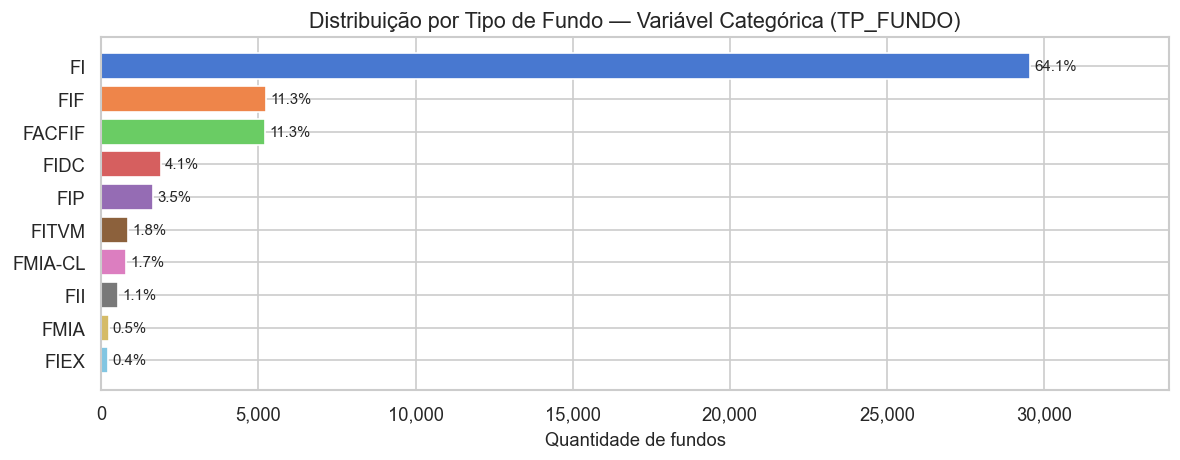

In [6]:
contagem = cad["TP_FUNDO"].value_counts().head(10)
total    = contagem.sum()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    contagem.index[::-1],
    contagem.values[::-1],
    color=sns.color_palette("muted", len(contagem))[::-1],
    edgecolor="white"
)

# Rótulo de percentual
for bar, val in zip(bars, contagem.values[::-1]):
    ax.text(bar.get_width() + total * 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val/total*100:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Quantidade de fundos", fontsize=11)
ax.set_title("Distribuição por Tipo de Fundo — Variável Categórica (TP_FUNDO)", fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(0, contagem.max() * 1.15)

moda_val = contagem.index[0]
print(f"Moda (tipo mais comum): {moda_val} — {contagem.iloc[0]:,} fundos ({contagem.iloc[0]/total*100:.1f}%)")
plt.tight_layout()
plt.show()

### 6.2 Distribuição de uma Variável Contínua — Retorno Diário da Cota

O retorno diário é a variável contínua mais importante em gestão de risco — é com ela que calculamos VaR, volatilidade e modelos GARCH. O gráfico inclui a curva KDE para evidenciar a forma da distribuição e as linhas de média e mediana para verificar a assimetria.

Fundo selecionado: BRADESCO FI FINANCEIRO - CIC EM AÇÕES - RESP LIMITADA
CNPJ: 47.178.058/0001-93
Observações: 19 dias


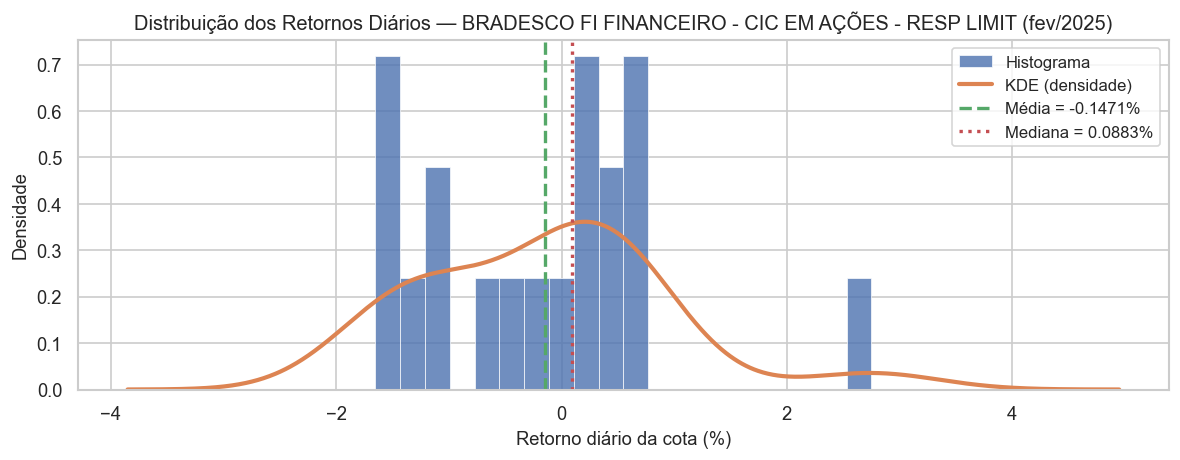


Estatísticas descritivas do retorno diário (%):
  Média          : -0.1471%
  Mediana        : 0.0883%
  Desvio padrão  : 1.0705%
  Variância      : 1.146017%²
  Mínimo / Máximo: -1.6511% / 2.7488%


In [7]:
# Seleciona o fundo com maior número médio de cotistas no mês
fundo_ref = (
    inf.groupby("CNPJ_FUNDO_CLASSE")["NR_COTST"]
    .mean()
    .idxmax()
)
nome_ref = cad.loc[cad["CNPJ_FUNDO"] == fundo_ref, "DENOM_SOCIAL"].values
nome_ref = nome_ref[0] if len(nome_ref) > 0 else fundo_ref

# Retornos diários desse fundo
ret_fundo = (
    inf[inf["CNPJ_FUNDO_CLASSE"] == fundo_ref]
    .sort_values("DT_COMPTC")["VL_QUOTA"]
    .pct_change()
    .dropna() * 100
)

print(f"Fundo selecionado: {nome_ref}")
print(f"CNPJ: {fundo_ref}")
print(f"Observações: {len(ret_fundo)} dias")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ret_fundo, bins=20, density=True, color="#4C72B0",
        edgecolor="white", linewidth=0.5, alpha=0.8, label="Histograma")
ret_fundo.plot.kde(ax=ax, color="#DD8452", linewidth=2.5, label="KDE (densidade)")
ax.axvline(ret_fundo.mean(),   color="#55A868", linewidth=2, linestyle="--",
           label=f"Média = {ret_fundo.mean():.4f}%")
ax.axvline(ret_fundo.median(), color="#C44E52", linewidth=2, linestyle=":",
           label=f"Mediana = {ret_fundo.median():.4f}%")

ax.set_xlabel("Retorno diário da cota (%)", fontsize=11)
ax.set_ylabel("Densidade", fontsize=11)
ax.set_title(f"Distribuição dos Retornos Diários — {nome_ref[:50]} (fev/2025)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nEstatísticas descritivas do retorno diário (%):")
print(f"  Média          : {ret_fundo.mean():.4f}%")
print(f"  Mediana        : {ret_fundo.median():.4f}%")
print(f"  Desvio padrão  : {ret_fundo.std():.4f}%")
print(f"  Variância      : {ret_fundo.var():.6f}%²")
print(f"  Mínimo / Máximo: {ret_fundo.min():.4f}% / {ret_fundo.max():.4f}%")

## 7. O que é um Modelo?

Um **modelo** é uma representação simplificada da realidade — uma forma de descrever, explicar ou prever fenômenos usando matemática e estatística.

Todo modelo começa com uma suposição: *"se eu simplificar o mundo desta maneira, consigo capturar o que importa"*.

### Componentes básicos de um modelo

1. **Variável de entrada (input / feature):** o que o modelo recebe como informação
2. **Variável de saída (output / target):** o que o modelo tenta explicar ou prever
3. **Parâmetros:** valores que o modelo aprende ou que são estimados a partir dos dados
4. **Regra / equação:** a lógica que transforma entrada em saída

### Exemplo intuitivo

> *"O retorno de um fundo hoje depende do retorno de ontem"*

Isso já é um modelo simples: define uma entrada (retorno de ontem), uma saída (retorno de hoje) e assume uma relação entre elas. Modelos mais sofisticados como **GARCH** ou **LSTM** seguem exatamente essa mesma lógica — só com mais variáveis e relações mais complexas.

### Tipos de modelo (visão geral)

| Tipo | Para que serve | Exemplo em finanças |
|------|---------------|---------------------|
| **Descritivo** | Resumir e entender os dados | Média, mediana, desvio padrão |
| **Probabilístico** | Modelar incerteza e distribuições | Distribuição normal dos retornos |
| **Preditivo** | Prever valores futuros | GARCH para volatilidade |
| **Prescritivo** | Indicar a melhor decisão | Otimização de portfólio (Markowitz) |

> **Nota:** modelos supervisionados (regressão, classificação, redes neurais) são um subconjunto dos modelos preditivos — serão abordados em notebooks futuros.

## 8. Resumo

| Conceito | Definição resumida | Aplicação em finanças |
|----------|-------------------|----------------------|
| **Média** | Soma ÷ n | Retorno esperado de um ativo |
| **Mediana** | Valor central da distribuição ordenada | Patrimônio "típico" dos fundos |
| **Moda** | Valor mais frequente | Tipo de fundo predominante no mercado |
| **Variância** | Desvio médio ao quadrado | Calculada internamente nos modelos de risco |
| **Desvio padrão** | Raiz da variância (mesma unidade dos dados) | Volatilidade — base do VaR e GARCH |
| **Média vs. Mediana** | Diferença revela assimetria | Com outliers, mediana é mais representativa |
| **Modelo** | Representação simplificada da realidade | Do descritivo ao preditivo (GARCH, LSTM) |

---

## Referências

- [CVM — Dados Abertos de Fundos de Investimento](https://dados.cvm.gov.br)
- Triola, M. F. — *Introdução à Estatística*
- Magalhães, M. N.; Lima, A. C. P. — *Noções de Probabilidade e Estatística* (IME-USP)